# Project Cycle 3 - Week A Draft Notebook

## Research Question

**Is the proportion of current cigarette use different between male and female students?**

This project compares current cigarette use between male and female students using the YRBS_2007 dataset.


## Variables

**Group Variable:**
- `WhatIsYourSex`

**Response Variable:**
- `CurrentCigaretteUse`

The response variable is binary after recoding:
- `1` = current cigarette use
- `0` = no current cigarette use


## Method Selection

Because the response variable is binary and the goal is to compare proportions between two independent groups, this project will use a **two-proportion z-test** in the next stage.

A two-sample t-test is not appropriate here because the response variable is categorical, not quantitative.


In [33]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1. Load Data

Make sure the file `YRBS_2007.csv` is saved in:

`data/raw/YRBS_2007.csv`


In [34]:
# Load the dataset
df = pd.read_csv("../data/raw/YRBS_2007.csv")

# Preview the first few rows
df.head()


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,...,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,...,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,...,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,...,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030


## 2. Select Required Variables

Only the group variable and response variable are needed for Week A.


In [35]:
# Select variables
df_selected = df[["WhatIsYourSex", "CurrentCigaretteUse"]].copy()

# Check missing values
df_selected.isna().sum()


WhatIsYourSex           13
CurrentCigaretteUse    718
dtype: int64

## 3. Clean Missing Values

Rows with missing values in the selected variables are removed.


In [36]:
# Remove missing values
df_clean = df_selected.dropna().copy()

# Check dataset size after cleaning
df_clean.shape


(13312, 2)

## 4. Recode Variables

### Gender
- `1` = Male
- `2` = Female

### Current Cigarette Use
- Original code `1` = no current cigarette use → recoded as `0`
- Original codes `2–7` = current cigarette use → recoded as `1`


In [37]:
# Recode gender
df_clean["gender"] = df_clean["WhatIsYourSex"].map({
    1: "Male",
    2: "Female"
})

# Recode current cigarette use
df_clean["smoke_now"] = np.where(
    df_clean["CurrentCigaretteUse"] == 1,
    0,
    1
)

# Remove rows with invalid gender values if any
df_clean = df_clean.dropna(subset=["gender"])

# Preview recoded data
df_clean.head()


,WhatIsYourSex,CurrentCigaretteUse,gender,smoke_now
0,2.0,7.0,Female,1
3,1.0,1.0,Male,0
4,1.0,1.0,Male,0
5,1.0,1.0,Male,0
6,1.0,1.0,Male,0


## 5. Descriptive Statistics

Before conducting inference, we first summarize the sample size and current cigarette use proportion in each gender group.


In [38]:
# Sample size by gender
sample_size = df_clean.groupby("gender").size().reset_index(name="n")
sample_size


,gender,n
0,Female,6572
1,Male,6740


In [39]:
# Summary table
summary_table = df_clean.groupby("gender").agg(
    n=("smoke_now", "size"),
    current_smokers=("smoke_now", "sum"),
    proportion_current_smoking=("smoke_now", "mean")
).reset_index()

summary_table


,gender,n,current_smokers,proportion_current_smoking
0,Female,6572,1418,0.215764
1,Male,6740,1167,0.173145


## 6. Visualization

This bar chart compares the proportion of current cigarette use between male and female students.


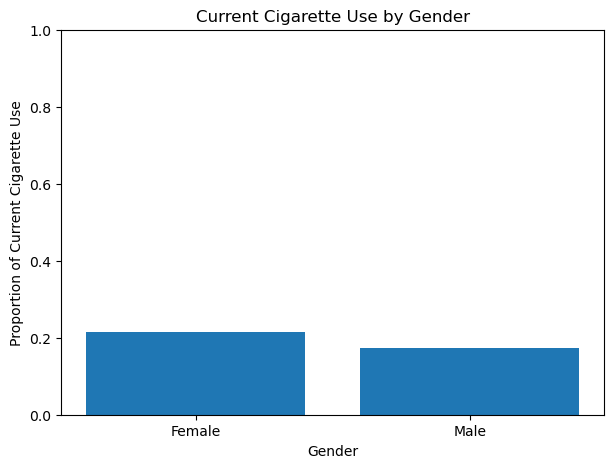

In [40]:
# Bar chart of current cigarette use proportion by gender
plt.figure(figsize=(7, 5))
plt.bar(summary_table["gender"], summary_table["proportion_current_smoking"])
plt.xlabel("Gender")
plt.ylabel("Proportion of Current Cigarette Use")
plt.title("Current Cigarette Use by Gender")
plt.ylim(0, 1)
plt.show()


## 7. Save Cleaned Data and Summary Table

The cleaned dataset and summary table can be saved for later use in Week B.


In [41]:
# Save cleaned data and summary table
# Make sure these folders exist before running this cell.

df_clean.to_csv("../data/processed/cycle3_cleaned_weekA.csv", index=False)
summary_table.to_csv("../outputs/tables/weekA_summary_table.csv", index=False)


## 8. Initial Interpretation

The descriptive statistics show the proportion of current cigarette use for male and female students.

At this stage, the analysis only describes the difference between the two groups. In Week B, a formal two-proportion z-test will be used to determine whether the difference is statistically significant.


# Hypotheses

Null Hypothesis (H0):
The proportion of current cigarette use is the same for male and female students.

Alternative Hypothesis (H1):
The proportion of current cigarette use is different for male and female students.

In [42]:
# Group counts

male = df_clean[df_clean["gender"] == "Male"]
female = df_clean[df_clean["gender"] == "Female"]

male_smokers = male["smoke_now"].sum()
female_smokers = female["smoke_now"].sum()

male_n = len(male)
female_n = len(female)

print("Male smokers:", male_smokers)
print("Male sample size:", male_n)

print("Female smokers:", female_smokers)
print("Female sample size:", female_n)

Male smokers: 1167
Male sample size: 6740
Female smokers: 1418
Female sample size: 6572


In [43]:
from statsmodels.stats.proportion import proportions_ztest

# Success counts
count = [male_smokers, female_smokers]

# Sample sizes
nobs = [male_n, female_n]

# Two-proportion z-test
z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -6.214820309970149
P-value: 5.138341623910967e-10


In [44]:
from statsmodels.stats.proportion import confint_proportions_2indep

# Confidence interval for difference in proportions
ci_low, ci_high = confint_proportions_2indep(
    male_smokers,
    male_n,
    female_smokers,
    female_n,
    method='wald'
)

print("95% Confidence Interval:")
print(ci_low, ci_high)

95% Confidence Interval:
-0.05605361482170604 -0.029183277235416107


In [45]:
male_prop = male_smokers / male_n
female_prop = female_smokers / female_n

difference = male_prop - female_prop

print("Male proportion:", male_prop)
print("Female proportion:", female_prop)
print("Difference in proportions:", difference)

Male proportion: 0.1731454005934718
Female proportion: 0.21576384662203288
Difference in proportions: -0.042618446028561074


In [46]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


# Interpretation

The analysis compares the proportion of current cigarette use between male and female students.

The two-proportion z-test provides evidence about whether the observed difference between the two groups is statistically significant.

The confidence interval estimates the plausible range for the true difference in cigarette use proportions between male and female students.

Why use two-proportion z-test?

Because the response variable is binary,
and we are comparing proportions between two independent groups.
What does the p-value mean?
The p-value measures the evidence against the null hypothesis.
A small p-value suggests the group proportions are significantly different.
What does the confidence interval mean?
The confidence interval gives a plausible range for the true difference in cigarette use proportions between male and female students.